# 定理2　共有 TCZ 収束定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 定理2は何を言っているのか

### 原文の主張

定理1は **一人** の心の話でした。定理2は **結びついた複数の主体**（家族・チームなど）を扱います。
主体 $i$ は自分のしんどさ $V_{0,i}$ に加えて、相手 $j$ との **ズレ料金** $\gamma_{ij}S_{ij}$ を払います。
$S_{ij}\ge0$ は「$i$ と $j$ の表象（頭の中の描像）のずれ」を測る量で、一致すれば $0$ です。

各主体は「自分のしんどさ ＋ みんなとのズレ料金」の合計を最小にするよう動きます。

$$
\pi_i=\arg\min_{u_i(\cdot)}\int\Bigl(V_{0,i}+\sum_j\gamma_{ij}S_{ij}\Bigr)\,ds
\quad\Longrightarrow\quad
\operatorname{dist}\bigl(\mathbf x(t),\mathrm{TCZ}_{\mathrm{shared,cl}}(t)\bigr)\longrightarrow0 .
$$

ここで $\mathbf x$ は全員の状態をまとめたベクトルで、$\mathrm{TCZ}_{\mathrm{shared}}$ は **全員の居心地ゾーンに同時に入り、かつズレが $0$ の点の集まり**（共有零集合 $\Omega_2$）です。
**前提：** 結合グラフが連結であること、$S_{ij}\ge0$、補題0の条件（下降条件と誤差境界）。

### 共有残差 $\Phi_2$

定理1の「はみ出し」を全員ぶんに足し、ズレ料金も足したものを **共有残差** と呼びます。

$$
\Phi_2(\mathbf x)=\sum_i w_i\,\bigl[V_{0,i}(x_i)-\theta_i\bigr]_+ \;+\;\gamma\,S_{12}(\mathbf x).
$$

$\Phi_2=0$ になるのは「全員が自分のゾーンの中にいて、しかもズレがない」ときだけです。
連結性のおかげで、誰かのはみ出しは必ず誰かのズレ料金に映るので、$\Phi_2$ 全体が補題0の下降条件を満たします。あとは定理1と同じ論法です。

### 大事な但し書き（原文§4「必要な追加条件」）

**双方向に結合しているだけでは、共有の谷に収束するとは限りません。**
そもそも「全員のゾーンに同時に入り、ズレもない」点（$\Omega_2$）が **空** なら、$\Phi_2=0$ にはなれず、不整合か個人の苦が正のまま残ります。ケース B がそれです。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| $x_i\in\mathbb R$ | 主体 $i=1,2$ の状態（表象は $h_i(x)=x$） | `x`（長さ2の配列） |
| $V_{0,i}(x)=(x-c_i)^2$ | 主体 $i$ のしんどさ。谷の底は $c_i$ | `V = (x - c)**2` |
| $\theta=0.1$ | しきい値（全員同じ） | `theta` |
| $S_{12}=(x_1-x_2)^2$ | 2人のズレ（$0\Leftrightarrow$ 表象一致） | `S` |
| $\gamma=2$ | ズレ料金の強さ | `gamma` |
| $\Phi_2$ | 共有残差 | `phi` |
| $\Omega_2=\{\Phi_2=0\}$ | 共有零集合 | （ケース A では $\{(z,z):\lvert z\rvert\le\sqrt\theta\}$） |

## 2. なぜこれが「定理2の例」と言えるのか

* 状態は2主体、グラフは「1と2を結ぶ1本の辺（双方向）」で **連結** です。ズレ $S_{12}\ge0$ は表象 $h_i(x)=x$ の差の2乗です。
* **ケース A**（$c=(0,0)$：2人の谷が **同じ場所**）：共有零集合 $\Omega_2=\{(z,z):|z|\le\sqrt\theta\}$ は **空でない**。定理の前提が成り立つ状況です。
* **ケース B**（$c=(0,3)$：2人の谷が **遠い**）：どの点でも $\Phi_2\ge3$ なので $\Omega_2=\emptyset$。但し書きの状況です。
* 動かし方は、$\Phi_2$ の（劣）勾配に沿って下る「共同方策」（コード中の `x = x - dt*20*g`）。

## 3. シミュレーション

In [1]:
# %% 準備
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

w, gamma, theta = np.array([1.0, 1.0]), 2.0, 0.1

def run(c, steps=4000, dt=0.002, x0=(2.0, -2.0)):
    c = np.asarray(c, float); x = np.array(x0, float); H = []
    for _ in range(steps):
        V = (x - c)**2
        S = (x[0] - x[1])**2
        phi = (w * np.maximum(V - theta, 0)).sum() + gamma * S
        H.append((phi, S, np.maximum(V - theta, 0).sum()))
        g = w * 2 * (x - c) * (V > theta)                  # [V-θ]+ の劣勾配
        g = g + gamma * 2 * (x[0] - x[1]) * np.array([1.0, -1.0])
        x = x - dt * 20 * g                                # Φ2 の勾配流(共同方策)
    return np.array(H)

A, B = run([0, 0]), run([0, 3.0])

出発点は両ケースとも $\mathbf x(0)=(2,-2)$。2人が互いに逆方向に遠く離れた状態から、$\Phi_2$ の勾配流で動かします。`H` には各ステップの（$\Phi_2$、ズレ $S_{12}$、個人残差の和）を記録しています。

## 4. 図を読む

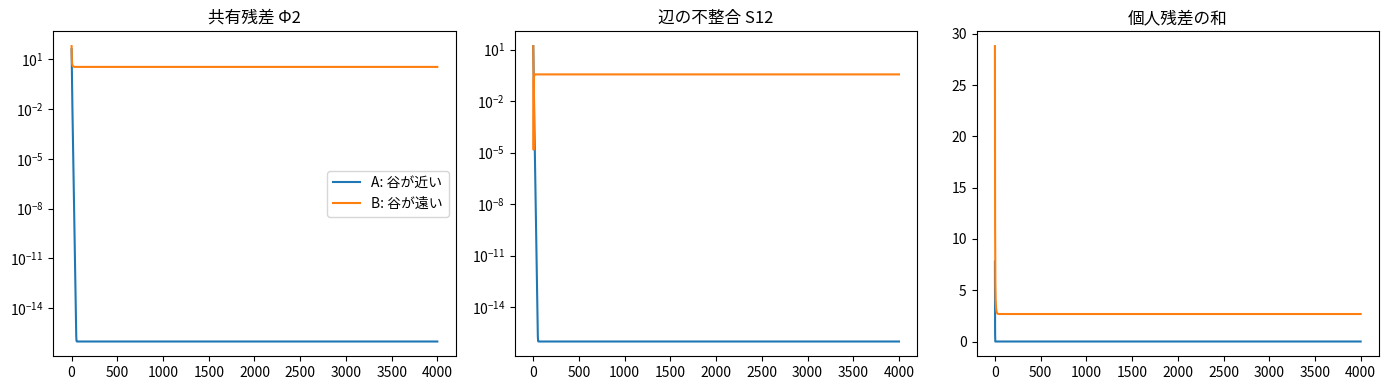

In [2]:
# %% 可視化
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for H, lab in [(A, "A: 谷が近い"), (B, "B: 谷が遠い")]:
    ax[0].semilogy(H[:, 0] + 1e-16, label=lab); ax[1].semilogy(H[:, 1] + 1e-16, label=lab)
    ax[2].plot(H[:, 2], label=lab)
ax[0].set_title("共有残差 Φ2"); ax[1].set_title("辺の不整合 S12"); ax[2].set_title("個人残差の和")
ax[0].legend(); plt.tight_layout(); plt.show()

縦軸が対数の2枚（左・中）と、通常の軸の1枚（右）です。青が A（谷が近い）、橙が B（谷が遠い）。

* **左：共有残差 $\Phi_2$（対数軸）。** 青は最初の数十ステップで急落し、$10^{-15}$ 付近（コードが $+10^{-16}$ を足しているので、そこが「0」の床）に張り付きます。**ほぼ $0$ に到達** しています。橙は最初に少し下がったあと、**約 $3.4$ で水平**。まったく減りません。
* **中：辺の不整合 $S_{12}$。** 青は同じく $0$（床）へ。橙は **約 $0.36$ のまま** 残ります（2人の状態の差 $\approx0.6$）。
* **右：個人残差の和。** 青は $0$。橙は **約 $2.7$** で一定です。$3.4\approx2.7+\gamma S_{12}=2.7+2\times0.36$ で、左の値と合っています。

A では「全員がゾーンの中にいて、ズレもなくなる」＝ $\Phi_2\to0$ が実現しました。これが定理2の結論（共有零集合への収束）です。
B ではズレを減らすと個人の苦が増え、個人の苦を減らすとズレが増えます。どちらかを払わざるをえず、どの $\mathbf x$ でも $\Phi_2\ge3$ なので $0$ になれません。「2人とも居心地よく、かつ一致」が **存在しない** からです。

## 5. 数値確認

In [3]:
# %% 数値確認
print("A: 最終 Φ2=%.2e, S12=%.2e" % (A[-1, 0], A[-1, 1]))
print("B: 最終 Φ2=%.2e, S12=%.2e  (正のまま残る)" % (B[-1, 0], B[-1, 1]))
assert A[-1, 0] < 1e-8 and B[-1, 1] > 0.1

A: 最終 Φ2=0.00e+00, S12=0.00e+00
B: 最終 Φ2=3.40e+00, S12=3.60e-01  (正のまま残る)


$A$ は $\Phi_2$ も $S_{12}$ も $10^{-8}$ 未満、$B$ は $S_{12}>0.1$ のまま、という2つの `assert` です。

## 6. Lean が検証した事実を、乱数で確認する

ここは Lean で **厳密に証明した** 事実を、念のため数値でも見る部分です（20000 点の乱数点）。

* B：すべての $\mathbf x$ で $\Phi_2\ge3$。
* A：誤差境界 $\operatorname{dist}(\mathbf x,\Omega_2)^2\le2\Phi_2(\mathbf x)$（距離は上限ノルム）。
* A：合意方策 $\dot x_i=-x_i$（共有零集合の点 $0$ への合意）に沿って、下降条件 $\Phi_2'\le-2\Phi_2$（$c=1$）。

In [4]:
# %% Lean が検証する事実の数値確認
rng = np.random.default_rng(1)
sq = np.sqrt(theta)
def Phi2(x, c): return sum(max((x[i] - c[i])**2 - theta, 0) for i in range(2)) + gamma * (x[0] - x[1])**2
# B: すべての x で Φ2 >= 3
pts = rng.uniform(-6, 8, size=(20000, 2))
print("B: min Φ2 =", min(Phi2(p, [0, 3.0]) for p in pts))
assert all(Phi2(p, [0, 3.0]) >= 3 for p in pts)
# A: 誤差境界 dist(x,Ω2)^2 <= 2Φ2 (sup 距離; Ω2={(z,z):|z|<=√θ})
def dist_to_Omega(x):
    z = np.clip((x[0] + x[1]) / 2, -sq, sq); return max(abs(x[0] - z), abs(x[1] - z))
assert all(dist_to_Omega(p)**2 <= 2 * Phi2(p, [0, 0]) + 1e-9 for p in pts)
# A: 合意方策 ẋ=-x, x(0)=(2,-2) で Φ2' <= -2Φ2
tt = np.linspace(0, 4, 4001); Pt = np.array([Phi2(np.array([2.0, -2.0]) * np.exp(-u), [0, 0]) for u in tt])
dP = np.gradient(Pt, tt)
print("A(合意方策): max(Φ'+2Φ) =", (dP + 2 * Pt)[1:-1].max())
assert (dP + 2 * Pt)[1:-1].max() < 1e-2

B: min Φ2 = 3.401472861703791
A(合意方策): max(Φ'+2Φ) = -1.4341731118666656e-08


B の $\Phi_2$ の最小値は約 $3.40>3$ で、Lean の下界 $\Phi_2\ge3$ と矛盾しません。A の合意方策では $\max(\Phi_2'+2\Phi_2)\approx-1.4\times10^{-8}\le0$ で、下降条件が成り立っています。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **縁起（つながりの中で成り立つ）の最初のかたち。** 原文は、定理2を「家族が、チームが、時間とともに一つの安定へ collapse していく現象の骨格」と説明しています。個人の谷が、結びつきによって **共有の谷** にそろっていく、という絵です。
* **ズレ料金 $\gamma S$** は「他者とのずれ」にかかるコストです。ずれを払い続けるより、谷をそろえるほうが全体のしんどさは小さい。
* **ケース B の読み方の一例。** 「結びつきがあるだけでは和合しない」。2人の谷（求めるもの）が遠いと、結びつきの強さをいくら上げても、不整合か個人の苦のどちらかが残ります。定理3（共通の屋根 LUB へ引き上げる）は、まさにこの「谷が遠い」場合に、より高い抽象度で共通点を見つけるための定理です。

## 8. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem2_SharedTCZ.lean`（共有 TCZ の基礎と合意方策）と `Tomabechi/Examples/Theorem2_SubgradientFlow.lean`（連続時間の劣勾配流）。どちらも一般定理 `theorem2_state_pair_conditional_conclusion` を呼び出します。

| | 内容 | 状態 |
| --- | --- | --- |
| A（$c=(0,0)$）の**劣勾配流の連続時間版** | 上のコードの更新則 $\dot{\mathbf x}\in-20\,\partial\Phi_2(\mathbf x)$（Euler 法の刻みを 0 にした極限）。初期値 $(2,-2)$、閾値 $\sqrt\theta$ を通過する前後で率 $200$・$160$ に切り替わる対称な厳密軌道を書き下し、その軌道が選んだ劣勾配に対する流れの方程式を（切替の 1 時刻を除いて）満たすこと、絶対連続、a.e. 下降 $\Phi_2'\le-2\Phi_2$（$c=1$）、誤差境界 $\operatorname{dist}^2\le2\Phi_2$（**すべての** $\mathbf x$）、$\Omega_2$ 非空、連結性を証明し、定理2の定量結論（距離・個人残差・不整合の指数減衰）へ接続 | 証明済 |
| A の補助：合意方策 $\dot x_i=-x_i$ | 同じ前提を満たす別の軌道（下のコードの確認と同じ） | 証明済 |
| B（$c=(0,3)$） | すべての $\mathbf x$ で $\Phi_2\ge3$（共有零集合は空） | 証明済 |
| 上の図 A・B の **Euler 離散化の軌道・数値** | 連続時間の極限を証明したのであって、離散化の誤差や数値出力は証明していない | **未証明** |

* 劣勾配流の「選んだ劣勾配」は、閾値の上だけ hinge の勾配 $2x$ を取り、閾値以下では 0 とするものです。一般の劣微分包含の解の存在・一意性を示したのではなく、具体解を書き下してその性質を証明しています。
* もとの Python では A を $c=(0,0.5)$ としていましたが、誤差境界を厳密に示せるよう **$c=(0,0)$ に変更** しました。
* ケース B は「前提（$\Omega_2\neq\emptyset$）を外したときの挙動」で、定理2そのものの反例ではありません。